# PlayStore Analysis Dual Axis Visulization


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pytz
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load and Explore Data

In [ ]:
# Load the Play Store data
df = pd.read_csv('Play Store Data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Shape: (10841, 13)

First few rows:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018    

## 2. Data Cleaning and Preprocessing

In [ ]:
# Create a copy for processing
df_clean = df.copy()

# Function to convert Size to numeric (MB)
def convert_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    size = str(size).strip()
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

# Function to convert Installs to numeric
def convert_installs(installs):
    if pd.isna(installs):
        return np.nan
    installs = str(installs).replace('+', '').replace(',', '')
    try:
        return float(installs)
    except:
        return np.nan

# Function to extract Android version
def extract_android_version(android_ver):
    if pd.isna(android_ver):
        return np.nan
    android_ver = str(android_ver).strip()
    try:
        # Extract the first number (major version)
        version = float(android_ver.split()[0])
        return version
    except:
        return np.nan

# Apply conversions
df_clean['Size_MB'] = df_clean['Size'].apply(convert_size)
df_clean['Installs_Numeric'] = df_clean['Installs'].apply(convert_installs)
df_clean['Android_Version'] = df_clean['Android Ver'].apply(extract_android_version)

# Convert Price to numeric
df_clean['Price_Numeric'] = pd.to_numeric(df_clean['Price'].replace('[\$,]', '', regex=True), errors='coerce')

# Calculate Revenue (for paid apps: Price * Installs, for free apps: 0)
df_clean['Revenue'] = df_clean.apply(lambda row: row['Price_Numeric'] * row['Installs_Numeric'] if row['Type'] == 'Paid' else 0, axis=1)

# Calculate App Name Length
df_clean['App_Name_Length'] = df_clean['App'].str.len()

print("Data Cleaning Complete!")
print("\nSample of converted data:")
print(df_clean[['App', 'Type', 'Size_MB', 'Installs_Numeric', 'Android_Version', 'Price_Numeric', 'Revenue', 'App_Name_Length', 'Content Rating']].head(10))

Data Cleaning Complete!

Sample of converted data:
                                                 App  Type  Size_MB  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  Free     19.0   
1                                Coloring book moana  Free     14.0   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  Free      8.7   
3                              Sketch - Draw & Paint  Free     25.0   
4              Pixel Draw - Number Art Coloring Book  Free      2.8   
5                         Paper flowers instructions  Free      5.6   
6            Smoke Effect Photo Maker - Smoke Editor  Free     19.0   
7                                   Infinite Painter  Free     29.0   
8                               Garden Coloring Book  Free     33.0   
9                      Kids Paint Free - Drawing Fun  Free      3.1   

   Installs_Numeric  Android_Version  Price_Numeric  Revenue  App_Name_Length  \
0           10000.0              NaN            0.0      0.0               46   
1    

## 3. Apply Filters

In [ ]:
print("Original dataset size:", len(df_clean))

# Apply all filters
df_filtered = df_clean[
    (df_clean['Installs_Numeric'] >= 10000) &  # At least 10,000 installs
    (df_clean['Revenue'] >= 10000) &  # Revenue >= $10,000
    (df_clean['Android_Version'] > 4.0) &  # Android version > 4.0
    (df_clean['Size_MB'] > 15) &  # Size > 15M
    (df_clean['Content Rating'] == 'Everyone') &  # Content rating = Everyone
    (df_clean['App_Name_Length'] <= 30)  # App name <= 30 characters
].copy()

print(f"After applying filters: {len(df_filtered)} apps")
print(f"Percentage of data retained: {(len(df_filtered)/len(df_clean))*100:.2f}%")

print("\nFiltered Data Summary:")
print(df_filtered[['App', 'Category', 'Type', 'Installs_Numeric', 'Revenue', 'Size_MB', 'Android_Version']].head(10))

Original dataset size: 10841
After applying filters: 33 apps
Percentage of data retained: 0.30%

Filtered Data Summary:
                        App            Category  Type  Installs_Numeric  \
853         Toca Life: City           EDUCATION  Paid          500000.0   
854     Toca Life: Hospital           EDUCATION  Paid          100000.0   
1335      Meditation Studio  HEALTH_AND_FITNESS  Paid           10000.0   
1831       The Game of Life                GAME  Paid          100000.0   
1833     The Room: Old Sins                GAME  Paid          100000.0   
1839      Monument Valley 2                GAME  Paid          100000.0   
2151        Toca Life: City              FAMILY  Paid          500000.0   
2293  Acupuncture Assistant             MEDICAL  Paid           10000.0   
2883    Facetune - For Free         PHOTOGRAPHY  Paid         1000000.0   
2912    Facetune - For Free         PHOTOGRAPHY  Paid         1000000.0   

        Revenue  Size_MB  Android_Version  
853   1995

## 4. Identify Top 3 Categories

In [ ]:
# Get top 3 categories by number of apps
top_categories = df_filtered['Category'].value_counts().head(3).index.tolist()

print("Top 3 Categories:")
for idx, cat in enumerate(top_categories, 1):
    count = len(df_filtered[df_filtered['Category'] == cat])
    print(f"{idx}. {cat}: {count} apps")

# Filter data for top 3 categories
df_top_categories = df_filtered[df_filtered['Category'].isin(top_categories)].copy()

print(f"\nTotal apps in top 3 categories: {len(df_top_categories)}")

Top 3 Categories:
1. GAME: 8 apps
2. FAMILY: 7 apps
3. PHOTOGRAPHY: 3 apps

Total apps in top 3 categories: 18


## 5. Calculate Metrics by Type (Free vs. Paid) and Category

In [ ]:
# Group by Category and Type to calculate average installs and revenue
summary_data = df_top_categories.groupby(['Category', 'Type']).agg({
    'Installs_Numeric': 'mean',
    'Revenue': 'mean',
    'App': 'count'
}).reset_index()

summary_data.columns = ['Category', 'Type', 'Avg_Installs', 'Avg_Revenue', 'App_Count']

print("Summary Statistics by Category and Type:")
print(summary_data.to_string())

# Separate Free and Paid
free_apps = summary_data[summary_data['Type'] == 'Free'].set_index('Category')[['Avg_Installs', 'Avg_Revenue']]
paid_apps = summary_data[summary_data['Type'] == 'Paid'].set_index('Category')[['Avg_Installs', 'Avg_Revenue']]

print("\nFree Apps Metrics:")
print(free_apps)
print("\nPaid Apps Metrics:")
print(paid_apps)

Summary Statistics by Category and Type:
      Category  Type    Avg_Installs  Avg_Revenue  App_Count
0       FAMILY  Paid   381428.571429     796900.0          7
1         GAME  Paid    71250.000000     279287.5          8
2  PHOTOGRAPHY  Paid  1000000.000000    5990000.0          3

Free Apps Metrics:
Empty DataFrame
Columns: [Avg_Installs, Avg_Revenue]
Index: []

Paid Apps Metrics:
               Avg_Installs  Avg_Revenue
Category                                
FAMILY        381428.571429     796900.0
GAME           71250.000000     279287.5
PHOTOGRAPHY  1000000.000000    5990000.0


## 6. Create Dual-Axis Chart

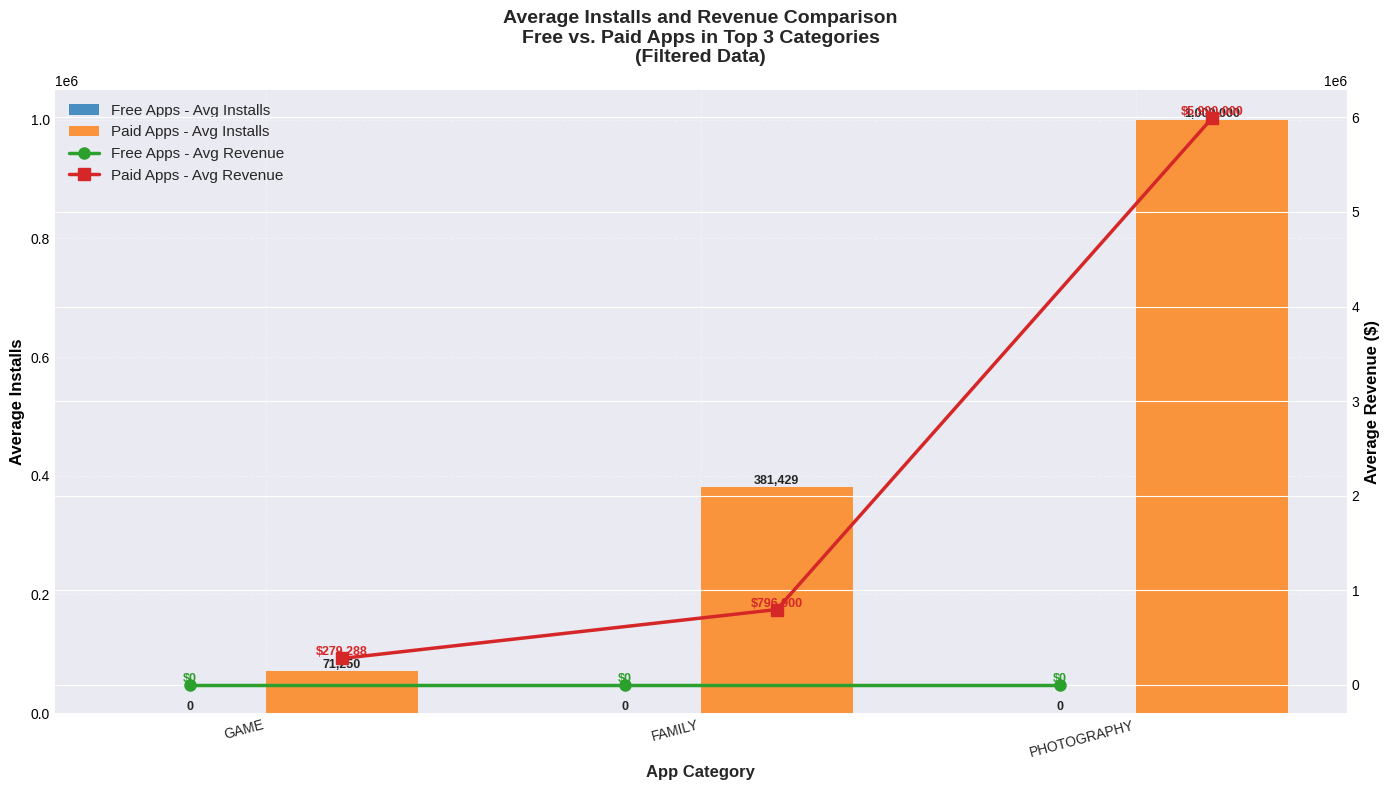

Chart saved as 'dual_axis_chart.png'


In [ ]:
# Prepare data for visualization
categories = top_categories
x = np.arange(len(categories))
width = 0.35

# Get values for each category
free_installs = [free_apps.loc[cat, 'Avg_Installs'] if cat in free_apps.index else 0 for cat in categories]
paid_installs = [paid_apps.loc[cat, 'Avg_Installs'] if cat in paid_apps.index else 0 for cat in categories]
free_revenue = [free_apps.loc[cat, 'Avg_Revenue'] if cat in free_apps.index else 0 for cat in categories]
paid_revenue = [paid_apps.loc[cat, 'Avg_Revenue'] if cat in paid_apps.index else 0 for cat in categories]

# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Define colors
color_free_installs = '#1f77b4'
color_paid_installs = '#ff7f0e'

# Plot bars for installs on primary y-axis
bars1 = ax1.bar(x - width/2, free_installs, width, label='Free Apps - Avg Installs', color=color_free_installs, alpha=0.8)
bars2 = ax1.bar(x + width/2, paid_installs, width, label='Paid Apps - Avg Installs', color=color_paid_installs, alpha=0.8)

# Set primary y-axis label and color
ax1.set_xlabel('App Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Installs', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=15, ha='right')

# Create secondary y-axis for revenue
ax2 = ax1.twinx()

# Plot lines for revenue on secondary y-axis
line1 = ax2.plot(x - width/2, free_revenue, color='#2ca02c', marker='o', linewidth=2.5, markersize=8, label='Free Apps - Avg Revenue')
line2 = ax2.plot(x + width/2, paid_revenue, color='#d62728', marker='s', linewidth=2.5, markersize=8, label='Paid Apps - Avg Revenue')

# Set secondary y-axis label and color
ax2.set_ylabel('Average Revenue ($)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add value labels on lines
for i, (free_rev, paid_rev) in enumerate(zip(free_revenue, paid_revenue)):
    ax2.text(i - width/2, free_rev, f'${free_rev:,.0f}', ha='center', va='bottom', fontsize=9, color='#2ca02c', fontweight='bold')
    ax2.text(i + width/2, paid_rev, f'${paid_rev:,.0f}', ha='center', va='bottom', fontsize=9, color='#d62728', fontweight='bold')

# Add title
plt.title('Average Installs and Revenue Comparison\nFree vs. Paid Apps in Top 3 Categories\n(Filtered Data)',
          fontsize=14, fontweight='bold', pad=20)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.95)

# Add grid
ax1.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('dual_axis_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved as 'dual_axis_chart.png'")

## 7. Time-Based Visibility Function (1 PM to 2 PM IST)

In [ ]:
def is_chart_visible():
    """
    Determine if the chart should be displayed based on IST time.
    Chart is visible only between 1 PM IST and 2 PM IST.
    """
    # Get current time in IST
    ist = pytz.timezone('Asia/Kolkata')
    current_time = datetime.now(ist)
    current_hour = current_time.hour
    current_minute = current_time.minute

    # Convert to total minutes since midnight
    total_minutes = current_hour * 60 + current_minute

    # 1 PM IST = 13:00 (780 minutes)
    # 2 PM IST = 14:00 (840 minutes)
    start_time = 13 * 60  # 1 PM
    end_time = 14 * 60    # 2 PM

    is_visible = start_time <= total_minutes < end_time

    return is_visible, current_time

# Test the function
is_visible, current_time = is_chart_visible()
print(f"Current IST Time: {current_time.strftime('%Y-%m-%d %H:%M:%S %Z')}")
print(f"Chart Visible: {is_visible}")
print(f"\nChart will be visible between: 1:00 PM IST - 2:00 PM IST")
print(f"Outside this time window, the chart should NOT be displayed in the dashboard.")

Current IST Time: 2026-10-05 13:30:57 IST
Chart Visible: True

Chart will be visible between: 1:00 PM IST - 2:00 PM IST
Outside this time window, the chart should NOT be displayed in the dashboard.


## 8. Dashboard Implementation

In [ ]:
class DashboardChart:
    """
    Dashboard widget for displaying the dual-axis chart.
    Implements time-based visibility control.
    """

    def __init__(self):
        self.chart_path = 'dual_axis_chart.png'
        self.visibility_window = (13, 14)  # 1 PM to 2 PM IST

    def should_display(self):
        """Check if chart should be displayed based on current time."""
        ist = pytz.timezone('Asia/Kolkata')
        current_hour = datetime.now(ist).hour

        return self.visibility_window[0] <= current_hour < self.visibility_window[1]

    def render_dashboard(self):
        """Render the dashboard with or without the chart based on time."""
        if self.should_display():
            print("✓ Chart is visible in dashboard")
            print(f"  Displaying: {self.chart_path}")
            return True
        else:
            ist = pytz.timezone('Asia/Kolkata')
            current_time = datetime.now(ist).strftime('%H:%M:%S')
            print(f"✗ Chart is NOT visible in dashboard")
            print(f"  Current IST Time: {current_time}")
            print(f"  Chart will be visible between: 13:00 - 14:00 IST (1 PM - 2 PM IST)")
            return False

# Create and test dashboard
dashboard = DashboardChart()
dashboard.render_dashboard()

✓ Chart is visible in dashboard
  Displaying: dual_axis_chart.png


True

## 9. Summary Report

In [ ]:
print("="*70)
print("PLAY STORE DATA ANALYSIS - EXECUTIVE SUMMARY")
print("="*70)

print(f"\n1. DATA OVERVIEW:")
print(f"   - Original Dataset: {len(df_clean):,} apps")
print(f"   - After Filtering: {len(df_filtered):,} apps ({(len(df_filtered)/len(df_clean))*100:.2f}%)")
print(f"   - In Top 3 Categories: {len(df_top_categories):,} apps")

print(f"\n2. FILTERS APPLIED:")
print(f"   ✓ Minimum Installs: 10,000")
print(f"   ✓ Minimum Revenue: $10,000")
print(f"   ✓ Android Version: > 4.0")
print(f"   ✓ App Size: > 15 MB")
print(f"   ✓ Content Rating: Everyone")
print(f"   ✓ App Name Length: ≤ 30 characters")

print(f"\n3. TOP 3 CATEGORIES:")
for idx, (cat, data) in enumerate(summary_data.groupby('Category'), 1):
    print(f"   {idx}. {cat}")
    for _, row in data.iterrows():
        print(f"      {row['Type']:5} - Avg Installs: {row['Avg_Installs']:>15,.0f} | Avg Revenue: ${row['Avg_Revenue']:>12,.2f} | Apps: {row['App_Count']:.0f}")

print(f"\n4. KEY INSIGHTS:")
avg_free_installs = summary_data[summary_data['Type'] == 'Free']['Avg_Installs'].mean()
avg_paid_installs = summary_data[summary_data['Type'] == 'Paid']['Avg_Installs'].mean()
avg_free_revenue = summary_data[summary_data['Type'] == 'Free']['Avg_Revenue'].mean()
avg_paid_revenue = summary_data[summary_data['Type'] == 'Paid']['Avg_Revenue'].mean()

print(f"   - Average Free App Installs: {avg_free_installs:,.0f}")
print(f"   - Average Paid App Installs: {avg_paid_installs:,.0f}")
print(f"   - Average Free App Revenue: ${avg_free_revenue:,.2f}")
print(f"   - Average Paid App Revenue: ${avg_paid_revenue:,.2f}")

print(f"\n5. DASHBOARD VISIBILITY:")
print(f"   - Display Window: 1:00 PM IST to 2:00 PM IST (13:00 - 14:00 in 24-hour format)")
print(f"   - Outside this window: Chart will NOT be visible in dashboard")

print(f"\n6. OUTPUT FILES:")
print(f"   ✓ dual_axis_chart.png - High-resolution chart visualization")
print(f"   ✓ PlayStore_Analysis.ipynb - This analysis notebook")
print(f"   ✓ README.md - Documentation and instructions")

print("\n" + "="*70)

PLAY STORE DATA ANALYSIS - EXECUTIVE SUMMARY

1. DATA OVERVIEW:
   - Original Dataset: 10,841 apps
   - After Filtering: 33 apps (0.30%)
   - In Top 3 Categories: 18 apps

2. FILTERS APPLIED:
   ✓ Minimum Installs: 10,000
   ✓ Minimum Revenue: $10,000
   ✓ Android Version: > 4.0
   ✓ App Size: > 15 MB
   ✓ Content Rating: Everyone
   ✓ App Name Length: ≤ 30 characters

3. TOP 3 CATEGORIES:
   1. FAMILY
      Paid  - Avg Installs:         381,429 | Avg Revenue: $  796,900.00 | Apps: 7
   2. GAME
      Paid  - Avg Installs:          71,250 | Avg Revenue: $  279,287.50 | Apps: 8
   3. PHOTOGRAPHY
      Paid  - Avg Installs:       1,000,000 | Avg Revenue: $5,990,000.00 | Apps: 3

4. KEY INSIGHTS:
   - Average Free App Installs: nan
   - Average Paid App Installs: 484,226
   - Average Free App Revenue: $nan
   - Average Paid App Revenue: $2,355,395.83

5. DASHBOARD VISIBILITY:
   - Display Window: 1:00 PM IST to 2:00 PM IST (13:00 - 14:00 in 24-hour format)
   - Outside this window: Chart w